# Lesson 3: Overfitting vs Underfitting

## Objective
- Understand underfitting, good fit, and overfitting
- See them visually using plots
- Learn why test performance matters more than training performance


## Intuition

A good model should capture the real pattern in data,
not memorize noise and not be too simple.

- Underfitting: model is too simple
- Good fit: model captures the true trend
- Overfitting: model memorizes the data


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression #base regression model
from sklearn.preprocessing import PolynomialFeatures #allows curved models
from sklearn.model_selection import train_test_split #separete train/test
from sklearn.metrics import mean_squared_error #evaluation metrics

In [ ]:
X = np.array([40, 50, 60, 70, 80, 90, 100]).reshape(-1, 1) #feautues(sizes m²)
y = np.array([78, 102, 118, 145, 158, 182, 205]) #labels
#prices with slight noise (realistic)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## Reminder:
- Model will never see test data during training
- Test data simulates the real world

In [ ]:
underfit_model = LinearRegression()
underfit_model.fit(X_train, y_train)

X_line = np.linspace(40, 100, 100).reshape(-1, 1)
y_underfit = underfit_model.predict(X_line)

## Explanation:
- This model can only learn a straight line
- If the data is slightly nonlinear → problem

## Good Fit Model (Moderate Complexity)

In [ ]:
poly_2 = PolynomialFeatures(degree=2)
X_train_poly2 = poly_2.fit_transform(X_train)
X_line_poly2 = poly_2.transform(X_line)

good_model = LinearRegression()
good_model.fit(X_train_poly2, y_train)

y_good = good_model.predict(X_line_poly2)

## Overfitting Model (Too Complex)

In [14]:
poly_6 = PolynomialFeatures(degree=6)
X_train_poly6 = poly_6.fit_transform(X_train)
X_line_poly6 = poly_6.transform(X_line)

overfit_model = LinearRegression()
overfit_model.fit(X_train_poly6, y_train)

y_overfit = overfit_model.predict(X_line_poly6)


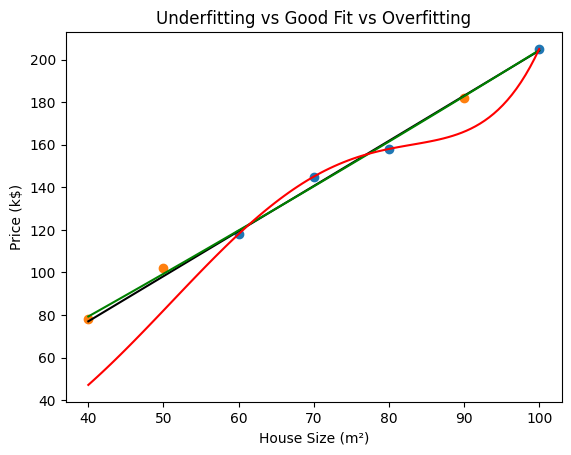

In [24]:
plt.scatter(X_train, y_train)
plt.scatter(X_test, y_test)

plt.plot(X_line, y_underfit, color='black')
plt.plot(X_line, y_good, color='green')
plt.plot(X_line, y_overfit, color='red')

plt.xlabel("House Size (m²)")
plt.ylabel("Price (k$)")
plt.title("Underfitting vs Good Fit vs Overfitting")
plt.show()


## Quantitative Proof (Errors)

In [ ]:
# Predictions on test data
y_test_under = underfit_model.predict(X_test)

y_test_good = good_model.predict(
    poly_2.transform(X_test)
)

y_test_over = overfit_model.predict(
    poly_6.transform(X_test)
)

print("Underfit MSE:", mean_squared_error(y_test, y_test_under))
print("Good fit MSE:", mean_squared_error(y_test, y_test_good))
print("Overfit MSE:", mean_squared_error(y_test, y_test_over))


Underfit MSE: 5.480000000000039
Good fit MSE: 3.1039669421498135
Overfit MSE: 9953515263741.562
